The purpose is to provide descriptive statistics on disclosure rate of 
* Different industries
* Different metrics

Descriptive Statistics of SASB Disclosure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import seaborn as sns

plt.rcParams['font.family'] = 'Book Antiqua'   # or 'Arial', 'DejaVu Sans', etc.
plt.rcParams['font.size'] = 12 

In [2]:
## Set the working directory

base1 = Path(r"C:\Users\huipingr\Dropbox\4_SASB\Data and Coding\SASB Metrics and Data (working).xlsx")
base2 = Path(r"D:\Dropbox\Dropbox\Dropbox\4_SASB\Data and Coding\SASB Metrics and Data (working).xlsx")

if base1.exists():
    base = base1
elif base2.exists():
    base = base2
else:
    raise FileNotFoundError("Neither path exists")

print("Using file:", base)

Using file: D:\Dropbox\Dropbox\Dropbox\4_SASB\Data and Coding\SASB Metrics and Data (working).xlsx


In [3]:
Metrics = pd.read_excel(base, sheet_name = "Metrics")
Metrics = Metrics[['Code', 'Quantitative', 'MonetaryLoss']]

Sample_metrics = pd.read_excel(base, sheet_name = "List of Sample Metrics")
Sample_metrics = Sample_metrics[['Line in Master', 'Company', 'Industry', 'Code', 'Metrics', 'Reported']]

Sample_metrics[['Line in Master', 'Company', 'Industry']] = Sample_metrics[['Line in Master', 'Company', 'Industry']].ffill()

Sample_metrics = Sample_metrics.merge(Metrics, on='Code', how='left')
print("Total number of firms:", Sample_metrics['Company'].nunique())
print("Total number of report-metrics:", len(Sample_metrics))

print("Total number of report-metrics after excluding non-applicable metrics:", len(Sample_metrics[Sample_metrics['Reported']!=2]))
# Sample_metrics.to_csv('List of Sample Metrics.csv', index=False)
Sample_metrics.head()

Total number of firms: 256
Total number of report-metrics: 5725
Total number of report-metrics after excluding non-applicable metrics: 5576


,Line in Master,Company,Industry,Code,Metrics,Reported,Quantitative,MonetaryLoss
0,10.0,AdvanSix Inc,CHEMICALS,RT-CH-110a.1,"Gross global Scope 1 emissions, percentage cov...",1,1.0,NaN
1,10.0,AdvanSix Inc,CHEMICALS,RT-CH-110a.2,Discussion of long-term and short-term strateg...,1,0.0,NaN
2,10.0,AdvanSix Inc,CHEMICALS,RT-CH-120a.1,Air emissions of the following pollutants: (1)...,1,0.0,NaN
3,10.0,AdvanSix Inc,CHEMICALS,RT-CH-130a.1,"(1) Total energy consumed, (2) percentage grid...",1,1.0,NaN
4,10.0,AdvanSix Inc,CHEMICALS,RT-CH-140a.1,"(1) Total water withdrawn, (2) total water con...",1,1.0,NaN


No. of Insustries in each SASB report

In [4]:
table = (Sample_metrics.groupby('Line in Master')['Industry'].nunique()
         .value_counts().sort_index()
         .rename_axis('# of SASB Industries per Report')
         .reset_index(name='# of Sustainability Reports'))

table['%'] = (table['# of Sustainability Reports'] / table['# of Sustainability Reports'].sum() * 100).round(2)
table.loc[len(table)] = ['Total', table['# of Sustainability Reports'].sum(), 100]
table

,# of SASB Industries per Report,# of Sustainability Reports,%
0,1,253,83.77
1,2,30,9.93
2,3,10,3.31
3,4,1,0.33
4,5,4,1.32
5,6,3,0.99
6,8,1,0.33
7,Total,302,100.00


* Coverage of industries
* Required Topics and Disclosure Rate of each Topics
* Quantitative or qualitative

Then move to industries that require disclosures of monetary loss

In [5]:
print("Sample Size:", Sample_metrics['Line in Master'].nunique())
print("# of unique firms", Sample_metrics['Company'].nunique())
print("# of report-industry pairs", 
      Sample_metrics[['Line in Master', 'Industry']].drop_duplicates().shape[0])

Sample Size: 302
# of unique firms 256
# of report-industry pairs 393


Description of "not applicable" and "not disclosed" metrics

In [6]:
## "not applicable" Metrics

list_of_metrics = pd.read_excel(base, sheet_name="List of Sample Metrics (fill)")
notapp = list_of_metrics[list_of_metrics['Reported'] == 2]

summary = pd.concat([
    notapp['Reason Summary'].value_counts(),
    notapp.groupby('Reason Summary')['Line in Master'].nunique(),
    notapp.groupby('Reason Summary')['Industry'].nunique()
], axis=1)

summary.columns = ['# of Metrics', '# of Sustainability Reports', '# of SASB industries']
summary['%'] = (summary['# of Metrics'] / summary['# of Metrics'].sum() * 100).round(2)

summary = summary.reset_index().rename(columns={'index': 'Reasons'})

# add total row
summary.loc[len(summary)] = ['Total',
                            summary['# of Metrics'].sum(),
                            notapp['Line in Master'].nunique(),
                            notapp['Industry'].nunique(),
                            100]
summary

,Reason Summary,# of Metrics,# of Sustainability Reports,# of SASB industries,%
0,Doesn't engage underlying activity,111,43,23,84.09
1,Not specified,16,8,7,12.12
2,Not material,3,2,2,2.27
3,Undefined number,2,1,1,1.52
4,Total,132,56,30,100.00


In [7]:
len(list_of_metrics)

5735

In [8]:
## "not disclosed" Metrics

notdis = list_of_metrics[list_of_metrics['Reported'] == 0]
print(len(notdis))


notdis['Reason Summary'] = notdis['Reason Summary'].fillna("No reason provided")


summary = pd.concat([
    notdis['Reason Summary'].value_counts(),
    notdis.groupby('Reason Summary')['Line in Master'].nunique(),
    notdis.groupby('Reason Summary')['Industry'].nunique()
], axis=1)

summary.columns = ['# of Metrics', '# of Sustainability Reports', '# of SASB industries']
summary['%'] = (summary['# of Metrics'] / summary['# of Metrics'].sum() * 100).round(2)

summary = summary.reset_index().rename(columns={'index': 'Reasons'})

# add total row
summary.loc[len(summary)] = ['Total',
                            summary['# of Metrics'].sum(),
                            notapp['Line in Master'].nunique(),
                            notapp['Industry'].nunique(),
                            100]
summary

1768


C:\Users\huipi\AppData\Local\Temp\ipykernel_33768\2618935393.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  notdis['Reason Summary'] = notdis['Reason Summary'].fillna("No reason provided")


,Reason Summary,# of Metrics,# of Sustainability Reports,# of SASB industries,%
0,No reason provided,1583,178,59,89.54
1,Plan to disclose in the future,46,21,16,2.60
2,Disclosed alternative information,43,23,15,2.43
3,Data not available,31,17,11,1.75
4,Do not track the data,14,8,8,0.79
5,Do not calculate the metrics,13,10,6,0.74
6,Materiality under evaluation,9,2,3,0.51
7,Confidential,9,6,4,0.51
8,Not material,8,6,5,0.45
9,Feasibility not clear yet,7,5,5,0.40


Industry distribution

In [9]:
Sample_metrics[['code_ind1', 'code_ind2', 'code_topic']] = (
    Sample_metrics['Code']
    .str.extract(r'^([A-Z]+)-([A-Z]+)-(\d+)')
)

print("# of general industry:", Sample_metrics['code_ind1'].nunique())

Sample_metrics['ind_code'] = (
    Sample_metrics['code_ind1'] + '-' + Sample_metrics['code_ind2']
)

# No. of reports per industry (Export)
Sample_metrics.groupby(['ind_code','Industry'])['Line in Master'].nunique().reset_index(name='# of reports')

# of general industry: 11


,ind_code,Industry,# of reports
0,CG-AA,"APPAREL, ACCESSORIES & FOOTWEAR",12
1,CG-AM,APPLIANCE MANUFACTURING,1
2,CG-BF,BUILDING PRODUCTS & FURNISHINGS,1
3,CG-EC,E-COMMERCE,2
4,CG-HP,HOUSEHOLD & PERSONAL PRODUCTS,6
...,...,...,...
67,TR-AU,AUTOMOBILES,3
68,TR-CL,CRUISE LINES,2
69,TR-MT,MARINE TRANSPORTATION,6
70,TR-RA,RAIL TRANSPORTATION,2


Industry Analysis

In [10]:
# No. of metrics in each industry group
ind1 = (
    Sample_metrics.groupby('ind_code')['Code']
    .nunique()
    .reset_index(name='N_metrics')
)

# Export
ind1

,ind_code,N_metrics
0,CG-AA,11
1,CG-AM,6
2,CG-BF,6
3,CG-EC,13
4,CG-HP,9
...,...,...
67,TR-AU,12
68,TR-CL,20
69,TR-MT,14
70,TR-RA,10


Firms' Disclosure Rate

In [11]:
# Not consider quantitative or qualitative metrics

# Sample_metrics['N_Reported_ind'] = (Sample_metrics['Reported'] == 1).groupby([Sample_metrics['Line in Master'], Sample_metrics['Industry']]).transform('sum')

# Sample_metrics['N_ind'] = (
#     Sample_metrics.groupby(['Line in Master', 'Industry'])['Code']
#     .transform('size')
# )

# Sample_metrics['Report_rate'] = Sample_metrics['N_Reported_ind']/Sample_metrics['N_ind']

# # Report rate by each topic
# Sample_metrics['code_maintopic'] = Sample_metrics['Code'].str.extract(r'^[A-Z]+-[A-Z]+-(\d)').astype(int)
# Sample_metrics['N_Reported_ind_topic'] = (Sample_metrics['Reported'] == 1).groupby([Sample_metrics['Line in Master'], Sample_metrics['Industry'], Sample_metrics['code_maintopic']]).transform('sum')
# Sample_metrics['N_ind_topic'] = (
#     Sample_metrics.groupby(['Line in Master', 'Industry', 'code_maintopic'])['Code']
#     .transform('size')
# )
# Sample_metrics['Report_rate_topic'] = Sample_metrics['N_Reported_ind_topic']/Sample_metrics['N_ind_topic']

# # Sample_metrics.head()

In [12]:
## Report rate by Quantitative or qualitative metrics

Sample_metrics['N_ind'] = (
    Sample_metrics
    .groupby(['Line in Master', 'Industry', 'Quantitative'])['Code']
    .transform('size')
)

# numerator: number of reported metrics (Reported == 1) per firm–industry × type
Sample_metrics['N_reported_ind'] = (
    (Sample_metrics['Reported'] == 1)
    .groupby([Sample_metrics['Line in Master'], Sample_metrics['Industry'], Sample_metrics['Quantitative']])
    .transform('sum')
)

# denominator: number of applicable metrics (exclude Reported == 2) per firm–industry × type
Sample_metrics['N_required_ind'] = (
    (Sample_metrics['Reported'] != 2)
    .groupby([Sample_metrics['Line in Master'], Sample_metrics['Industry'], Sample_metrics['Quantitative']])
    .transform('sum')
)

# avoid divide-by-zero: set rate to NaN where no required metrics exist
Sample_metrics['Report_rate'] = np.where(
    Sample_metrics['N_required_ind'] > 0,
    Sample_metrics['N_reported_ind'] / Sample_metrics['N_required_ind'],
    np.nan
)

In [13]:
firm_ind_rates = (
    Sample_metrics
    .drop_duplicates(['Line in Master', 'Industry', 'Quantitative', 'ind_code'])
    [['Line in Master', 'Industry', 'ind_code', 'Quantitative', 'Report_rate', 'code_ind1']]
)

ind_report_rate_by_type = (
    firm_ind_rates
    .groupby(['ind_code', 'Industry','Quantitative'])['Report_rate']
    .mean()
    .unstack()
)

ind_report_rate_by_type = ind_report_rate_by_type.rename(
    columns={0: 'Qualitative', 1: 'Quantitative'}
)

ind_report_rate_by_type = ind_report_rate_by_type.sort_values(
    by='Quantitative'
)

# Export
ind_report_rate_by_type.round(3)

,Quantitative,Qualitative,Quantitative
ind_code,Industry,,
FB-TB,TOBACCO,1.000,0.000
HC-MC,MANAGED CARE,0.500,0.000
HC-DY,HEALTH CARE DELIVERY,0.429,0.167
CG-EC,E-COMMERCE,0.125,0.167
HC-DR,DRUG RETAILERS,0.500,0.188
...,...,...,...
TR-AL,AIRLINES,1.000,1.000
EM-IS,IRON & STEEL PRODUCERS,1.000,1.000
CG-AM,APPLIANCE MANUFACTURING,1.000,1.000


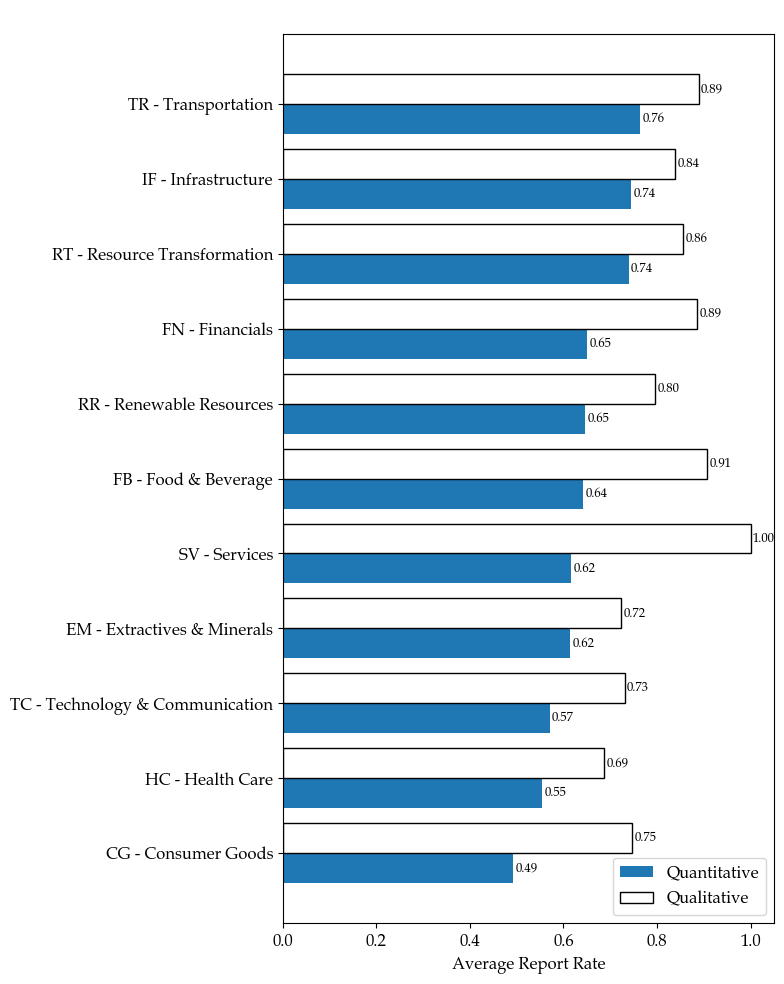

In [14]:
## Disclosure rate by main SASB industries

ind_report_rate_by_type = (
    firm_ind_rates
    .groupby(['code_ind1', 'Quantitative'])['Report_rate']
    .mean()
    .unstack()
)

ind_report_rate_by_type = ind_report_rate_by_type.rename(
    columns={0: 'Qualitative', 1: 'Quantitative'}
)

ind_report_rate_by_type = ind_report_rate_by_type.sort_values(
    by='Quantitative'
)

## Plot

fig, ax = plt.subplots(figsize=(8, 10))

y = np.arange(len(ind_report_rate_by_type))
bar_height = 0.4

# Industry labels
ind_map = {
    'CG': 'CG - Consumer Goods',
    'EM': 'EM - Extractives & Minerals',
    'FB': 'FB - Food & Beverage',
    'FN': 'FN - Financials',
    'HC': 'HC - Health Care',
    'IF': 'IF - Infrastructure',
    'RR': 'RR - Renewable Resources',
    'RT': 'RT - Resource Transformation',
    'SV': 'SV - Services',
    'TC': 'TC - Technology & Communication',
    'TR': 'TR - Transportation'
}
ind_labels = [ind_map.get(code, code) for code in ind_report_rate_by_type.index]

# Bars
bars_qt = ax.barh(
    y - bar_height / 2,
    ind_report_rate_by_type['Quantitative'],
    height=bar_height,
    label='Quantitative',
    # color='grey'
)

bars_ql = ax.barh(
    y + bar_height / 2,
    ind_report_rate_by_type['Qualitative'],
    height=bar_height,
    label='Qualitative',
    color='white',
    edgecolor='black'
)

# Y-axis labels
ax.set_yticks(y)
ax.set_yticklabels(ind_labels)

# Axis & title
ax.set_xlabel('Average Report Rate')
ax.set_title(' ')
ax.legend()

# ---- Add value labels on bars ----
for bars in [bars_ql, bars_qt]:
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width + 0.005,                      # slightly to the right
            bar.get_y() + bar.get_height()/2,
            f'{width:.2f}',                    # format to 2 decimals
            va='center',
            ha='left',
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [16]:
# aggregate counts per firm–industry × type
tmp = (
    Sample_metrics
    .groupby(['Line in Master', 'Industry', 'Quantitative'])
    .agg(
        N_required=('Reported', lambda s: (s != 2).sum()),   # exclude 2
        N_reported=('Reported', lambda s: (s == 1).sum())
    )
    .reset_index()
)

# report rate per firm–industry × type (NaN if no required metrics)
tmp['Report_rate'] = np.where(tmp['N_required'] > 0,
                              tmp['N_reported'] / tmp['N_required'],
                              np.nan)

# topic/industry-level equal-weighted mean (here for Quantitative vs Qualitative)
tmp.groupby('Quantitative')['Report_rate'].mean()

Quantitative
0.0    0.814521
1.0    0.649315
Name: Report_rate, dtype: float64

In [ ]:
# Sample_metrics['N_Reported_ind_quant'] = (Sample_metrics['Reported'] == 1).groupby([Sample_metrics['Line in Master'], Sample_metrics['Industry'], Sample_metrics['Quantitative']]).transform('sum')

# Sample_metrics['N_ind_quant'] = (
#     Sample_metrics.groupby(['Line in Master', 'Industry', 'Quantitative'])['Code']
#     .transform('size')
# )

# Sample_metrics['Report_rate_quant'] = Sample_metrics['N_Reported_ind_quant']/Sample_metrics['N_ind_quant']

# # Report rate by each topic
# Sample_metrics['code_maintopic'] = Sample_metrics['Code'].str.extract(r'^[A-Z]+-[A-Z]+-(\d)').astype(int)
# Sample_metrics['N_Reported_topic_quant'] = (Sample_metrics['Reported'] == 1).groupby([Sample_metrics['Line in Master'], Sample_metrics['Industry'], Sample_metrics['code_maintopic'], Sample_metrics['Quantitative']]).transform('sum')
# Sample_metrics['N_ind_topic_quant'] = (
#     Sample_metrics.groupby(['Line in Master', 'Industry', 'code_maintopic', 'Quantitative'])['Code']
#     .transform('size')
# )
# Sample_metrics['Report_rate_topic_quant'] = Sample_metrics['N_Reported_topic_quant']/Sample_metrics['N_ind_topic_quant']

In [ ]:
## Earlier code - which shows industry-weighted report rate

# df_plot = Sample_metrics.groupby(['code_ind1', 'Quantitative'])['Reported'].mean().unstack()

# df_plot = df_plot.rename(columns={0: 'Qualitative', 1: 'Quantitative'})

# ind_map = {
#     'CG': 'Consumer Goods', 'EM': 'Extractives & Minerals',
#     'FB': 'Food & Beverage', 'FN': 'Financials',
#     'HC': 'Health Care', 'IF': 'Infrastructure',
#     'RR': 'Renewable Resources', 'RT': 'Resource Transformation',
#     'SV': 'Services', 'TC': 'Technology & Communication',
#     'TR': 'Transportation'
# }
# df_plot.index = [f"{c} – {ind_map.get(c, c)}" for c in df_plot.index]

# df_plot = df_plot.sort_values(by='Quantitative', ascending=True)

# ax = df_plot.plot(
#     kind='barh', 
#     figsize=(10, 8), 
#     width=0.8, 
#     color=['white', 'grey'], 
#     edgecolor='black'
# )

# for container in ax.containers:
#     ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

# plt.title('Average Report Rate by Industry (Qualitative vs Quantitative)')
# plt.xlabel('Report Rate')
# plt.ylabel('SASB Industry Sector')
# plt.xlim(0, 1.05) 
# plt.grid(True, axis='x', linestyle='--', alpha=0.5)

# plt.legend(loc='lower right')

# plt.tight_layout()
# plt.show()

II. Metrics that discloses monetary losses

In [17]:
Metrics = pd.read_excel(base, sheet_name = "Metrics")

Metrics = Metrics[['Industry', 'Topics', 'Code', 'Metrics', 'Quantitative','MonetaryLoss']]

Metrics['Industry'] = Metrics['Industry'].ffill()

loss = Metrics[Metrics['MonetaryLoss'] == 1]
loss = loss[['Industry', 'Topics', 'Code', 'Metrics']]

In [18]:
loss[['code_ind1', 'code_ind2', 'code_topic']] = (
    loss['Code'].str.extract(r'^([A-Z]+)-([A-Z]+)-(\d+)')
)

loss['ind_code'] = (
    loss['code_ind1'] + '-' + loss['code_ind2']
)

loss.head()

,Industry,Topics,Code,Metrics,code_ind1,code_ind2,code_topic,ind_code
2,ADVERTISING & MARKETING,Data Privacy,SV-AD-220a.3,Total amount of monetary losses as a result of...,SV,AD,220,SV-AD
3,ADVERTISING & MARKETING,Advertising Integrity,SV-AD-270a.1,Total amount of monetary losses as a result of...,SV,AD,270,SV-AD
15,AEROSPACE & DEFENSE,Product Safety,RT-AE-250a.4,Total amount of monetary losses as a result of...,RT,AE,250,RT-AE
19,AEROSPACE & DEFENSE,Business Ethics,RT-AE-510a.1,Total amount of monetary losses as a result of...,RT,AE,510,RT-AE
44,AIR FREIGHT & LOGISTICS,Labor Practices,TR-AF-310a.2,Total amount of monetary losses as a result of...,TR,AF,310,TR-AF


In [19]:
print(loss['ind_code'].nunique())

print(len(Sample_metrics), len(loss))
sample_loss = pd.merge(Sample_metrics[['Line in Master', 'Company','Industry', 'Code','Reported']], 
                       loss[['Code', 'Topics', 'Metrics', 'code_ind1','code_ind2', 'code_topic', 'ind_code']], on=['Code'], how='inner')

print(len(sample_loss))


print("No. of reports that cover monetary losses", sample_loss['Line in Master'].nunique())

loss_summary = (
    sample_loss
    .groupby('ind_code')
    .agg(
        Avg_Report_rate = ('Reported', lambda x: (x == 1).mean()),
        N_reports       = ('Line in Master', 'nunique')
    )
    .reset_index()
)

## Group by main industry code

loss_summary = (
    sample_loss
    .groupby('code_ind1')
    .agg(
        Avg_Report_rate = ('Reported', lambda x: (x == 1).mean()),
        N_reports       = ('Line in Master', 'nunique')
    )
    .reset_index()
)

loss_summary.sort_values(by='Avg_Report_rate', ascending=False)

45
5725 69
375
No. of reports that cover monetary losses 170


,code_ind1,Avg_Report_rate,N_reports
5,IF,0.900000,8
3,FN,0.741935,32
6,RT,0.709677,11
8,TC,0.645161,30
9,TR,0.619048,20
4,HC,0.579710,25
7,SV,0.538462,10
2,FB,0.468750,25
1,EM,0.409091,18
0,CG,0.272727,12


III. Individual metrics and metrics groups (first 80 characters)

* Frequency of each metrics group
* % of firms that disclosed it (conditional on at least one firm discloses the metrics). 

In [20]:
Metrics = pd.read_excel(base, sheet_name = "Metrics")
Metrics = Metrics[['Code', 'Quantitative', 'MonetaryLoss']]

Sample_metrics = pd.read_excel(base, sheet_name = "List of Sample Metrics")
Sample_metrics = Sample_metrics[['Line in Master', 'Company', 'Industry', 'Code', 'Metrics', 'Reported']]

Sample_metrics[['Line in Master', 'Company', 'Industry']] = Sample_metrics[['Line in Master', 'Company', 'Industry']].ffill()

print(len(Sample_metrics))
Sample_metrics = Sample_metrics.merge(Metrics, on='Code', how='left')

Sample_metrics["reported_adj"] = Sample_metrics["Reported"].replace(2, np.nan)
Sample_metrics['Quantitative'] = Sample_metrics['Quantitative'].fillna(1)   # EM-MM-150a.1/2/3 all quantitative

print(len(Sample_metrics))
Sample_metrics.head()

5725
5725


,Line in Master,Company,Industry,Code,Metrics,Reported,Quantitative,MonetaryLoss,reported_adj
0,10.0,AdvanSix Inc,CHEMICALS,RT-CH-110a.1,"Gross global Scope 1 emissions, percentage cov...",1,1.0,NaN,1.0
1,10.0,AdvanSix Inc,CHEMICALS,RT-CH-110a.2,Discussion of long-term and short-term strateg...,1,0.0,NaN,1.0
2,10.0,AdvanSix Inc,CHEMICALS,RT-CH-120a.1,Air emissions of the following pollutants: (1)...,1,0.0,NaN,1.0
3,10.0,AdvanSix Inc,CHEMICALS,RT-CH-130a.1,"(1) Total energy consumed, (2) percentage grid...",1,1.0,NaN,1.0
4,10.0,AdvanSix Inc,CHEMICALS,RT-CH-140a.1,"(1) Total water withdrawn, (2) total water con...",1,1.0,NaN,1.0


In [21]:
# The first 80 characters of the 'Metrics' column 
Sample_metrics["metrics80"] = Sample_metrics["Metrics"].str[:80]

## Average report rate for each metrics80

Sample_metrics.groupby("metrics80")["reported_adj"].agg(total_count="count", total_reported="sum", report_rate="mean").reset_index().round(3).sort_values("report_rate", ascending=False).to_csv("test.csv")

summary = (
    Sample_metrics
    .groupby("metrics80")
    .agg(
        total_count=("reported_adj", "count"),
        total_reported=("reported_adj", "sum"),
        report_rate=("reported_adj", "mean"),
        mean_quantitative=("Quantitative", "mean")   # ← add this
    )
    .reset_index()
    .round(3)
    .sort_values("report_rate", ascending=False)
)

# summary.to_csv("test.csv")


## Explore the determinants

* Quantitative vs. Qualitative
* Consumer-facing industry (B2C)

In [22]:
Consumer_exp = pd.read_excel(base, sheet_name = "Consumer exposure")
Consumer_exp

,Main Industry,SASB Industry,ind_code,Corresponding IO Industry,B2C
0,Consumer Goods,"APPAREL, ACCESSORIES & FOOTWEAR",CG-AA,Apparel and leather and allied products,1.885064
1,Consumer Goods,APPLIANCE MANUFACTURING,CG-AM,"Electrical equipment, appliances, and components",0.793532
2,Consumer Goods,BUILDING PRODUCTS & FURNISHINGS,CG-BF,Miscellaneous manufacturing,1.291311
3,Consumer Goods,E-COMMERCE,CG-EC,Miscellaneous manufacturing,1.291311
4,Consumer Goods,HOUSEHOLD & PERSONAL PRODUCTS,CG-HP,Housing,1.981288
...,...,...,...,...,...
72,Transportation,CRUISE LINES,TR-CL,Water transportation,1.642594
73,Transportation,CAR RENTAL & LEASING,TR-CR,Rental and leasing services and lessors of int...,0.338271
74,Transportation,MARINE TRANSPORTATION,TR-MT,Water transportation,1.642594
75,Transportation,RAIL TRANSPORTATION,TR-RA,Rail transportation,0.337964


In [23]:
Consumer_exp['B2C'].describe().round(3)

count    77.000
mean      0.852
std       0.597
min       0.000
25%       0.401
50%       0.794
75%       1.366
max       1.981
Name: B2C, dtype: float64

In [24]:
# quick inspect
print("Columns:", Consumer_exp.columns.tolist()[:50])
print("Sample rows:")
display(Consumer_exp.head())

# If you expect 'SASB Industry' but it's not in columns, check index
print("'SASB Industry' in columns?", 'SASB Industry' in Consumer_exp.columns)
print("'SASB Industry' in index?", 'SASB Industry' in Consumer_exp.index)

Columns: ['Main Industry', 'SASB Industry', 'ind_code', 'Corresponding IO Industry', 'B2C']
Sample rows:


,Main Industry,SASB Industry,ind_code,Corresponding IO Industry,B2C
0,Consumer Goods,"APPAREL, ACCESSORIES & FOOTWEAR",CG-AA,Apparel and leather and allied products,1.885064
1,Consumer Goods,APPLIANCE MANUFACTURING,CG-AM,"Electrical equipment, appliances, and components",0.793532
2,Consumer Goods,BUILDING PRODUCTS & FURNISHINGS,CG-BF,Miscellaneous manufacturing,1.291311
3,Consumer Goods,E-COMMERCE,CG-EC,Miscellaneous manufacturing,1.291311
4,Consumer Goods,HOUSEHOLD & PERSONAL PRODUCTS,CG-HP,Housing,1.981288


'SASB Industry' in columns? True
'SASB Industry' in index? False


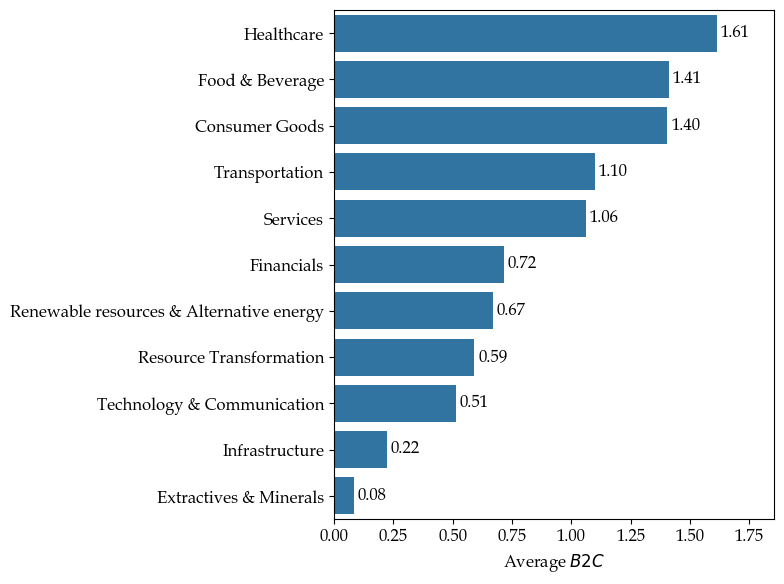

In [27]:
# Average B2C by Main Industry
df = (
    Consumer_exp
    .groupby('Main Industry', as_index=False)['B2C']
    .mean()
)

# Sort
df = df.sort_values('B2C', ascending=False)

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=df,
    x='B2C',
    y='Main Industry',
    order=df['Main Industry'].tolist()
)

# Add B2C value at the end of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.title('')
plt.xlabel(r'Average $\it{B2C}$')
plt.ylabel('')

# Give labels a little extra space
ax.set_xlim(0, df['B2C'].max() * 1.15)

plt.tight_layout()
plt.show()

In [ ]:
## Merge consumer exposure with sample metrics

Sample_metrics['ind_code'] = Sample_metrics['Code'].str[:5]
Sample_metrics.head()

,Line in Master,Company,Industry,Code,Metrics,Reported,Quantitative,MonetaryLoss,reported_adj,metrics80,ind_code
0,10.0,AdvanSix Inc,CHEMICALS,RT-CH-110a.1,"Gross global Scope 1 emissions, percentage cov...",1,1.0,NaN,1.0,"Gross global Scope 1 emissions, percentage cov...",RT-CH
1,10.0,AdvanSix Inc,CHEMICALS,RT-CH-110a.2,Discussion of long-term and short-term strateg...,1,0.0,NaN,1.0,Discussion of long-term and short-term strateg...,RT-CH
2,10.0,AdvanSix Inc,CHEMICALS,RT-CH-120a.1,Air emissions of the following pollutants: (1)...,1,0.0,NaN,1.0,Air emissions of the following pollutants: (1)...,RT-CH
3,10.0,AdvanSix Inc,CHEMICALS,RT-CH-130a.1,"(1) Total energy consumed, (2) percentage grid...",1,1.0,NaN,1.0,"(1) Total energy consumed, (2) percentage grid...",RT-CH
4,10.0,AdvanSix Inc,CHEMICALS,RT-CH-140a.1,"(1) Total water withdrawn, (2) total water con...",1,1.0,NaN,1.0,"(1) Total water withdrawn, (2) total water con...",RT-CH


In [ ]:
print(len(Sample_metrics))
merged = pd.merge(Sample_metrics, Consumer_exp, on=['ind_code'], how = 'left')

5725


Descriptive statistics

In [ ]:
merged['MonetaryLoss'] = merged['MonetaryLoss'].fillna(0)

# df = merged[merged['reported_adj'].notna()]
merged[['reported_adj', 'Quantitative','MonetaryLoss','B2C']].describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
reported_adj,5576.0,0.683,0.465,0.0,0.000,1.000,1.000,1.000
Quantitative,5725.0,0.730,0.444,0.0,0.000,1.000,1.000,1.000
MonetaryLoss,5725.0,0.066,0.247,0.0,0.000,0.000,0.000,1.000
B2C,5725.0,0.673,0.571,0.0,0.099,0.637,0.966,1.981


Correlation Metrics

Univariate Tests

In [ ]:
# tests = [
#     ("Quantitative (1 vs 0)", merged["Quantitative"] == 1),
#     ("Monetary Loss (1 vs 0)", merged["MonetaryLoss"] == 1),
#     ("High Consumer Exposure", merged["B2C"] > merged["B2C"].median()),
# ]

# rows = []
# for name, mask in tests:
#     g1 = merged.loc[mask, "reported_adj"].dropna()
#     g2 = merged.loc[~mask, "reported_adj"].dropna()
#     t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
#     rows.append((name, g1.size, g1.mean(), g2.size, g2.mean(), t_stat, p_val))

# pd.DataFrame(rows, columns=[
#     "test", "n1", "mean_group1", "n2", "mean_group2", "t_stat", "p_value"
# ]).round(3)


Multivariate Tests

In [ ]:
merged.to_stata("regression2.dta", write_index=False, version=118)

C:\Users\huipi\AppData\Local\Temp\ipykernel_6724\583237256.py:1: InvalidColumnName: 
Not all pandas column names were valid Stata variable names.
The following replacements have been made:

    Line in Master   ->   Line_in_Master
    Main Industry   ->   Main_Industry
    SASB Industry   ->   SASB_Industry
    Corresponding IO Industry   ->   Corresponding_IO_Industry

If this is not what you expect, please make sure you have Stata-compliant
column names in your DataFrame (strings only, max 32 characters, only
alphanumerics and underscores, no Stata reserved words)

  merged.to_stata("regression2.dta", write_index=False, version=118)
